# Run pipeline: all fires

Clean, repeatable batch runner. Fire selection/exploration/diagnostics stay in
`data.ipynb`; this notebook just runs `build_cell_table` over a defined list of
fires and saves the pooled result. Re-running is cheap once biomass/dNBR/forest-type
are cached locally (only new fires trigger a real Earth Engine wait).

Known issues that still apply to everything produced here (see README):
- GLAD height unreliable on steep terrain (#8) - exclude `<10m` from conclusions.
- CCI biomass sensitivity varies a lot by fire for unexplained reasons (Section 10).
- Fire Atlas `landcover` label does not reliably predict pixel-level forest type
  (Section 12) - always check `forest_type_label`, never the Atlas label.


In [1]:
import sys
sys.path.append("..")

import ee
ee.Authenticate()   # skip if already authenticated this session
ee.Initialize(project="tree-fire-510209")

import pandas as pd
from src.pipeline import build_cell_table
from src.fires import utm_epsg_for


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


## Fire configs

One entry per fire run so far (11 total): 4 NAM (Evergreen Needleleaf), 4 SE Asia
(mostly Evergreen Broadleaf), 3 new biomes (southern Africa, Amazon, Australia).
UTM zone is computed from each fire's coordinates rather than hardcoded.


In [2]:
fire_configs = [
    # NAM
    dict(uid="2020_112", lon=-122.782, lat=39.6938,
         pre_fire_window=("2020-07-01", "2020-08-10"), post_fire_window=("2021-07-01", "2021-08-31"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2020_135", lon=-121.094, lat=39.8396,
         pre_fire_window=("2020-07-01", "2020-08-15"), post_fire_window=("2021-07-01", "2021-08-31"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2020_464", lon=-122.128, lat=37.0396,
         pre_fire_window=("2020-07-01", "2020-08-10"), post_fire_window=("2021-07-01", "2021-08-31"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2021_190", lon=-120.556, lat=38.5896,
         pre_fire_window=("2021-06-15", "2021-08-10"), post_fire_window=("2022-06-15", "2022-08-31"),
         agb_before_year=2020, agb_after_years=[2022]),
    # SE Asia
    dict(uid="2020_841874", lon=101.5797, lat=18.8730,
         pre_fire_window=("2020-01-01", "2020-03-15"), post_fire_window=("2021-01-01", "2021-03-15"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2020_838262", lon=97.6276, lat=18.9896,
         pre_fire_window=("2019-11-01", "2020-01-20"), post_fire_window=("2020-11-01", "2021-01-20"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2020_818141", lon=94.8991, lat=24.6730,
         pre_fire_window=("2020-01-01", "2020-03-15"), post_fire_window=("2021-01-01", "2021-03-15"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2021_750951", lon=98.9752, lat=20.9855,
         pre_fire_window=("2021-01-01", "2021-03-10"), post_fire_window=("2022-01-01", "2022-03-10"),
         agb_before_year=2020, agb_after_years=[2022]),
    # new biomes
    dict(uid="2020_325095", lon=19.8160, lat=-7.3770,
         pre_fire_window=("2020-04-15", "2020-06-15"), post_fire_window=("2021-04-15", "2021-06-15"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2020_66789", lon=-52.0190, lat=-8.1812,
         pre_fire_window=("2020-06-01", "2020-08-15"), post_fire_window=("2021-06-01", "2021-08-15"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
    dict(uid="2020_901450", lon=153.3236, lat=-25.0645,
         pre_fire_window=("2020-08-01", "2020-10-10"), post_fire_window=("2021-08-01", "2021-10-10"),
         agb_before_year=2019, agb_after_years=[2021, 2022]),
]
print(len(fire_configs), "fires configured")


11 fires configured


## Scaling up: stratified sample, not just the biggest fires

Every fire run so far (the 11 above) was picked as the largest of its forest type
within a region. That's a size-biased sample (README Section 14), not representative
of the ~16,000 candidate fires, most of which are far smaller (median ~10 km2).

This draws a random sample per (GFED region, landcover) stratum instead, subject to
a minimum size so a fire has enough cells to be worth running at all, and excludes
fires already run above. Review the printed count before running - more fires means
a longer, though still parallelised, wait.


In [3]:
import numpy as np

already_run = {cfg["uid"] for cfg in fire_configs}
min_size_km2 = 20       # big enough to likely yield usable cells, small enough to not re-pick giants
n_per_stratum = 5        # tune this - it is the main lever on total runtime
seed = 0

sel_full = pd.read_parquet("../data/processed/forest_fires_2020_2021_attrs.parquet")

# uid (file_year + fire_ID) is not actually always unique - Section 5 already
# found that a repeated fire_ID is usually a genuinely different fire, not a
# duplicate row, and load_fire() has no way to disambiguate which one is meant.
# Drop any ambiguous uid from the candidate pool rather than guess.
dupe_uids = sel_full["uid"][sel_full["uid"].duplicated(keep=False)].unique()
print(len(dupe_uids), "ambiguous uids excluded from sampling")
candidates = sel_full[
    (sel_full["size"] >= min_size_km2)
    & (~sel_full["uid"].isin(already_run))
    & (~sel_full["uid"].isin(dupe_uids))
]

# plain loop, not groupby().apply() - that drops the grouping columns from the
# result on some pandas versions, which then breaks the groupby right after it
parts = []
for _, g in candidates.groupby(["GFED_regio", "landcover"]):
    parts.append(g.sample(n=min(n_per_stratum, len(g)), random_state=seed))
sampled = pd.concat(parts, ignore_index=True)

print(len(sampled), "fires sampled across", sampled.groupby(["GFED_regio", "landcover"]).ngroups, "strata")
print(sampled.groupby("landcover").size())

import importlib, src.fires
importlib.reload(src.fires)
from src.fires import derive_fire_params
new_fire_configs = [derive_fire_params(row) for _, row in sampled.iterrows()]


0 ambiguous uids excluded from sampling
145 fires sampled across 36 strata
landcover
Deciduous Broadleaf forest     37
Deciduous Needleleaf forest     5
Evergreen Broadleaf forest     39
Evergreen Needleleaf forest    31
Mixed forest                   33
dtype: int64


In [ ]:
import importlib
import src.fires, src.biomass, src.height, src.grids, src.severity, src.forest_type, src.temperature, src.pipeline
for m in [src.fires, src.biomass, src.height, src.grids, src.severity, src.forest_type, src.temperature, src.pipeline]:
    importlib.reload(m)

from src.pipeline import submit_severity_tasks, wait_and_download_severity, build_cell_table

# combine the hand-picked fires above with any stratified sample drawn in the
# "Scaling up" cell (that cell defines an empty list if it was not run)
all_fire_configs = fire_configs + globals().get("new_fire_configs", [])
print(len(all_fire_configs), "fires queued")

# phase 1: submit every fire's severity (dNBR + RBR) export at once (parallel on
# Earth Engine's servers), rather than waiting ~10-15 min per fire sequentially
submitted = submit_severity_tasks(all_fire_configs)
submitted = wait_and_download_severity(submitted)

# phase 2: now that every severity file is ready locally, build each fire's cell
# table - fast, since biomass/forest-type are cheap direct downloads, not batch exports
results = {}
for cfg in all_fire_configs:
    uid = cfg["uid"]
    lon, lat = cfg.pop("lon"), cfg.pop("lat")
    print("running", uid)
    try:
        results[uid] = build_cell_table(
            utm_epsg=utm_epsg_for(lon, lat),
            severity_path=submitted[uid]["severity_path"],
            **cfg,
        )
        print(uid, "done:", len(results[uid]), "cells")
    except Exception as e:
        print(uid, "FAILED:", e)
    cfg["lon"], cfg["lat"] = lon, lat


In [ ]:
import importlib, src.severity, src.pipeline
importlib.reload(src.severity)
importlib.reload(src.pipeline)
from src.pipeline import submit_severity_tasks, wait_and_download_severity

submitted = submit_severity_tasks(all_fire_configs)


In [ ]:
submitted = wait_and_download_severity(submitted)


In [ ]:
from src.pipeline import build_cell_table

results = {}
for cfg in all_fire_configs:
    uid = cfg["uid"]
    lon, lat = cfg.pop("lon"), cfg.pop("lat")
    print("running", uid)
    try:
        results[uid] = build_cell_table(
            utm_epsg=utm_epsg_for(lon, lat),
            severity_path=submitted[uid]["severity_path"],
            **cfg,
        )
        print(uid, "done:", len(results[uid]), "cells")
    except Exception as e:
        print(uid, "FAILED:", e)
    cfg["lon"], cfg["lat"] = lon, lat


In [15]:
print(len(results))
print(list(results[next(iter(results))].columns))


118
['uid', 'height', 'dnbr', 'rbr', 'forest_type', 'forest_type_label', 'a2019', 'a2021', 'a2022', 'severity', 'loss2021', 'loss2022']


In [16]:
import numpy as np, pandas as pd
import importlib, src.curves
importlib.reload(src.curves)
from src.curves import fit_all_groups

all_cells = pd.concat(results.values(), ignore_index=True)
all_cells["height_class"] = pd.cut(
    all_cells["height"], [0, 10, 20, np.inf],
    labels=["<10m", "10-20m", "gt20m"], right=False,
)

fits_dnbr = fit_all_groups(all_cells, dnbr_col="dnbr")
fits_rbr  = fit_all_groups(all_cells, dnbr_col="rbr")

compare = fits_dnbr.add_suffix("_dnbr").join(fits_rbr.add_suffix("_rbr"))
compare[["status_dnbr", "status_rbr", "l_max_dnbr", "l_max_rbr",
         "k_dnbr", "k_rbr", "n_fires_dnbr"]]


/home/jupyter/fire-impact-curves/notebooks/../src/curves.py:23: RuntimeWarning: overflow encountered in exp
  return l_max / (1 + np.exp(-k * (x - x0)))


status_dnbr         status_rbr l_max_dnbr  \
<10m   deciduous_broadleaf      degenerate_fit     degenerate_fit   0.135398   
       deciduous_needleleaf  insufficient_data  insufficient_data        NaN   
       evergreen_broadleaf              fitted     degenerate_fit   0.310899   
       evergreen_needleleaf     degenerate_fit     degenerate_fit   0.000839   
       mixed                    degenerate_fit     degenerate_fit   0.305214   
10-20m deciduous_broadleaf      degenerate_fit     degenerate_fit   0.177379   
       deciduous_needleleaf  insufficient_data  insufficient_data        NaN   
       evergreen_broadleaf              fitted             fitted   0.193948   
       evergreen_needleleaf             fitted             fitted   0.168593   
       mixed                            fitted             fitted   0.153117   
gt20m  deciduous_broadleaf      degenerate_fit     degenerate_fit   0.048484   
       deciduous_needleleaf  insufficient_data  insufficient_data        NaN   
       evergreen_broadleaf      degenerate_fit     degenerate_fit    0.24366   
       evergreen_needleleaf             fitted             fitted   0.396161   
       mixed                 insufficient_data  insufficient_data        NaN   

                            l_max_rbr     k_dnbr      k_rbr n_fires_dnbr  
<10m   deciduous_broadleaf   0.131964  47.399981  49.977665           29  
       deciduous_needleleaf       NaN        NaN        NaN            2  
       evergreen_broadleaf   0.311655  36.952368       50.0           46  
       evergreen_needleleaf  0.173682  25.469963  25.622861           27  
       mixed                 0.336337       50.0       50.0           17  
10-20m deciduous_broadleaf   0.188299  49.999996       50.0           40  
       deciduous_needleleaf       NaN        NaN        NaN            3  
       evergreen_broadleaf   0.181361  26.071068  36.985463           53  
       evergreen_needleleaf  0.180822  21.408301  28.015117           31  
       mixed                 0.247934  14.373543  23.326527           18  
gt20m  deciduous_broadleaf   0.144355  14.621247   14.43206           10  
       deciduous_needleleaf       NaN        NaN        NaN            1  
       evergreen_broadleaf    0.25598  49.999996  16.706715           34  
       evergreen_needleleaf  0.406143  13.973195  21.474488           27  
       mixed                      NaN        NaN        NaN           16

## Pool, check forest-type recovery, save

Compares the `unknown` share using the new two-band fallback (`forest_type_label`,
computed inside `build_cell_table`) against the old single-band approach, to see
how much the `discrete_classification` fallback actually recovered.


In [18]:
full = pd.concat([df.assign(uid=uid) for uid, df in results.items()], ignore_index=True)
full["height_class"] = pd.cut(full["height"], [0, 10, 20, 100], labels=["<10m", "10-20m", ">20m"])

print("fires:", full["uid"].nunique(), " total cells:", len(full))
print(full["forest_type_label"].value_counts(normalize=True))

# old (primary-band-only) unknown share, for comparison, using the raw forest_type codes
from src.forest_type import FOREST_TYPE_LABELS
old_label = full["forest_type"].map(FOREST_TYPE_LABELS)
print("old unknown share (forest_type band only):", (old_label == "unknown").mean())
print("new unknown share (with discrete_classification fallback):", (full["forest_type_label"] == "unknown").mean())


fires: 105  total cells: 482257
forest_type_label
evergreen_needleleaf    0.637859
evergreen_broadleaf     0.177928
unknown                 0.119552
not_forest              0.030770
mixed                   0.023166
deciduous_broadleaf     0.009839
deciduous_needleleaf    0.000885
Name: proportion, dtype: float64
old unknown share (forest_type band only): 0.17626701115795104
new unknown share (with discrete_classification fallback): 0.1195524378080567


In [19]:
import os
os.makedirs("../data/processed", exist_ok=True)
full.to_parquet("../data/processed/all_cells.parquet")
print("saved", len(full), "cells to ../data/processed/all_cells.parquet")


saved 482257 cells to ../data/processed/all_cells.parquet


## dNBR vs RBR: does RBR actually tighten cross-forest-type consistency?

Repeatable comparison (README Section 15). Fits every group twice, once on
`dnbr`, once on `rbr`, and lines up `l_max` side by side. Re-run this as more
fires are added, the Section 15 conclusion (RBR is a wash, not an improvement,
at 118 fires) may not hold forever, especially once Mixed/Deciduous groups
have enough fires to stop being `insufficient_data`.


In [20]:
fit_table_dnbr = fit_all_groups(full, dnbr_col="dnbr")
fit_table_rbr = fit_all_groups(full, dnbr_col="rbr")

compare = fit_table_dnbr.add_suffix("_dnbr").join(fit_table_rbr.add_suffix("_rbr"))
compare[["status_dnbr", "status_rbr", "l_max_dnbr", "l_max_rbr", "n_fires_dnbr"]]


/home/jupyter/fire-impact-curves/notebooks/../src/curves.py:23: RuntimeWarning: overflow encountered in exp
  return l_max / (1 + np.exp(-k * (x - x0)))


status_dnbr         status_rbr l_max_dnbr  \
<10m   deciduous_broadleaf      degenerate_fit     degenerate_fit    0.15031   
       deciduous_needleleaf  insufficient_data  insufficient_data        NaN   
       evergreen_broadleaf              fitted     degenerate_fit   0.312145   
       evergreen_needleleaf     degenerate_fit     degenerate_fit    0.00264   
       mixed                    degenerate_fit     degenerate_fit   0.305555   
10-20m deciduous_broadleaf      degenerate_fit     degenerate_fit   0.177379   
       deciduous_needleleaf  insufficient_data  insufficient_data        NaN   
       evergreen_broadleaf              fitted             fitted   0.193952   
       evergreen_needleleaf             fitted             fitted   0.168593   
       mixed                            fitted             fitted   0.153117   
>20m   deciduous_broadleaf      degenerate_fit     degenerate_fit   0.048484   
       deciduous_needleleaf  insufficient_data  insufficient_data        NaN   
       evergreen_broadleaf      degenerate_fit     degenerate_fit   0.243662   
       evergreen_needleleaf             fitted             fitted   0.396171   
       mixed                 insufficient_data  insufficient_data        NaN   

                            l_max_rbr n_fires_dnbr  
<10m   deciduous_broadleaf   0.152565           29  
       deciduous_needleleaf       NaN            2  
       evergreen_broadleaf   0.317433           46  
       evergreen_needleleaf  0.190951           27  
       mixed                 0.336456           17  
10-20m deciduous_broadleaf   0.188299           40  
       deciduous_needleleaf       NaN            3  
       evergreen_broadleaf   0.181368           53  
       evergreen_needleleaf  0.180822           31  
       mixed                 0.247934           18  
>20m   deciduous_broadleaf   0.144355           10  
       deciduous_needleleaf       NaN            1  
       evergreen_broadleaf    0.25705           34  
       evergreen_needleleaf  0.406148           27  
       mixed                      NaN           16

## Curve fits (draft, not final - uncertainty still wide, see README Section 12)

In [7]:
from src.curves import fit_all_groups, bootstrap_curve_band

fit_table = fit_all_groups(full)
print(fit_table)


                                        status     l_max          k        x0  \
<10m   deciduous_broadleaf      degenerate_fit   0.15031  49.999983  0.400164   
       deciduous_needleleaf  insufficient_data       NaN        NaN       NaN   
       evergreen_broadleaf              fitted  0.312145  44.770039  0.289289   
       evergreen_needleleaf     degenerate_fit   0.00264  25.629416  1.985957   
       mixed                    degenerate_fit  0.305555       50.0  0.772502   
10-20m deciduous_broadleaf      degenerate_fit  0.177379  49.999996   0.29623   
       deciduous_needleleaf  insufficient_data       NaN        NaN       NaN   
       evergreen_broadleaf              fitted  0.193952  26.066243  0.331552   
       evergreen_needleleaf             fitted  0.168593  21.408301  0.530799   
       mixed                            fitted  0.153117  14.373543  0.719878   
>20m   deciduous_broadleaf      degenerate_fit  0.048484  14.621247   1.82421   
       deciduous_needleleaf 

## Plot every usable (non-degenerate, past threshold) group

Generic - plots whatever is actually fitted, not a hardcoded group, so this keeps
working as more fires get added and different groups cross the usable threshold.


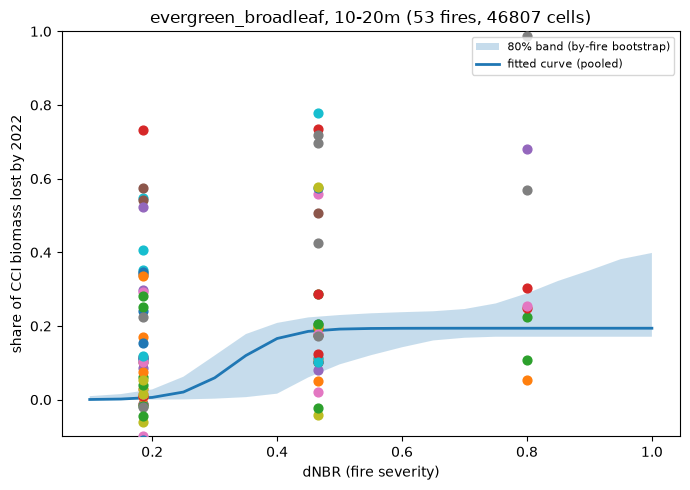

saved ../data/processed/curves/evergreen_broadleaf_10-20m.png


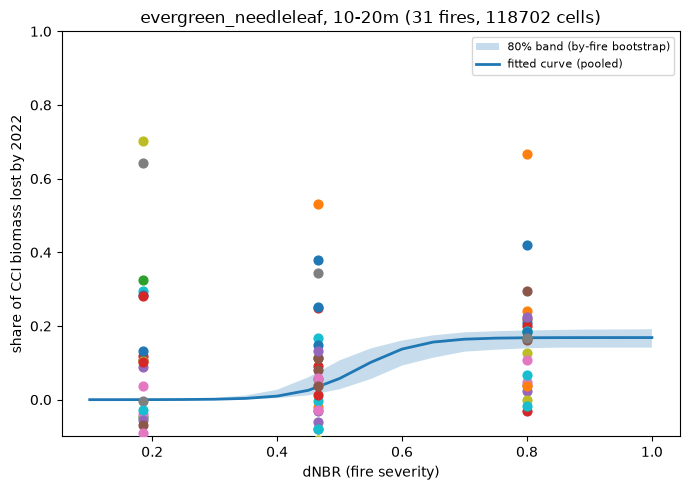

saved ../data/processed/curves/evergreen_needleleaf_10-20m.png


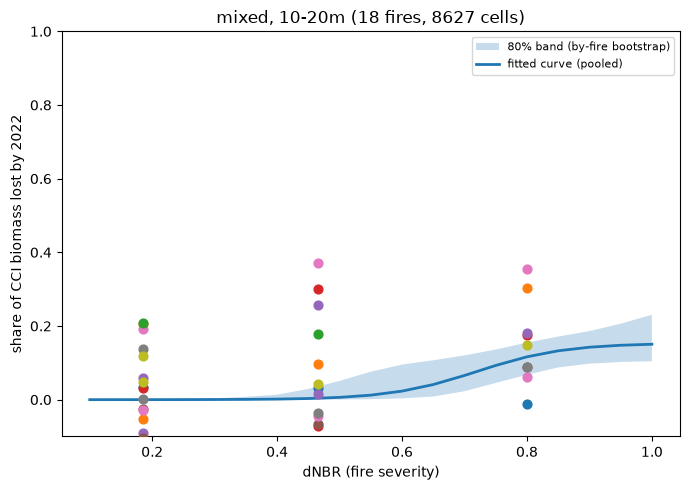

saved ../data/processed/curves/mixed_10-20m.png


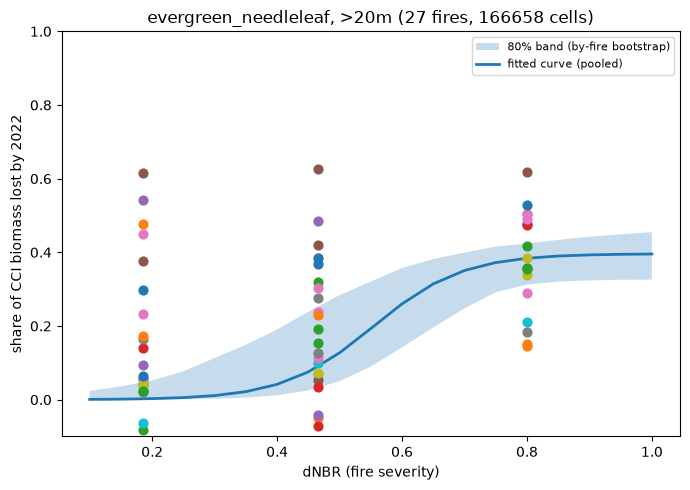

saved ../data/processed/curves/evergreen_needleleaf_gt20m.png
saved fit_parameters.csv and uncertainty_bands.csv


In [9]:
import matplotlib.pyplot as plt
from src.curves import bootstrap_curve_band, logistic

os.makedirs("../data/processed/curves", exist_ok=True)

# <10m excluded by policy (README known issue #8, GLAD height unreliable on steep
# terrain) regardless of fit status - a numerically clean fit does not make the
# underlying height measurement trustworthy
usable = fit_table[(fit_table["status"] == "fitted") & (fit_table.index.get_level_values(0) != "<10m")]

curve_records = []   # one row per group: the fitted parameters, saved below
band_records = []    # one row per group per dNBR grid point: the uncertainty band, saved below

for (height_class, forest_type), row in usable.iterrows():
    grp = full[(full["height_class"] == height_class) & (full["forest_type_label"] == forest_type)]
    band = bootstrap_curve_band(grp)
    if band is None:
        continue
    x_grid = band["dnbr"]

    curve_records.append({
        "height_class": height_class, "forest_type": forest_type,
        "l_max": row["l_max"], "k": row["k"], "x0": row["x0"],
        "n_fires": row["n_fires"], "n_cells": row["n_cells"],
    })
    band_df = band.copy()
    band_df["height_class"] = height_class
    band_df["forest_type"] = forest_type
    band_records.append(band_df)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.fill_between(x_grid, band["p10"], band["p90"], alpha=0.25, label="80% band (by-fire bootstrap)")
    ax.plot(x_grid, logistic(x_grid, row["l_max"], row["k"], row["x0"]), linewidth=2, label="fitted curve (pooled)")
    for uid, fire_grp in grp.groupby("uid"):
        means = fire_grp.groupby("severity", observed=True)["loss2022"].mean()
        sev_mid = {"mild": 0.185, "moderate": 0.465, "severe": 0.8}
        xs = [sev_mid[s] for s in means.index]
        ax.scatter(xs, means.values, s=40, zorder=5)

    ax.set_xlabel("dNBR (fire severity)")
    ax.set_ylabel("share of CCI biomass lost by 2022")
    ax.set_title(f"{forest_type}, {height_class} ({row['n_fires']} fires, {row['n_cells']} cells)")
    ax.legend(fontsize=8)
    ax.set_ylim(-0.1, 1.0)
    fig.tight_layout()
    fname = f"../data/processed/curves/{forest_type}_{height_class}.png".replace(">", "gt")
    fig.savefig(fname, dpi=150)
    plt.show()
    print("saved", fname)

# save the actual curve data, not just the images - this is the real deliverable
pd.DataFrame(curve_records).to_csv("../data/processed/curves/fit_parameters.csv", index=False)
pd.concat(band_records, ignore_index=True).to_csv("../data/processed/curves/uncertainty_bands.csv", index=False)
print("saved fit_parameters.csv and uncertainty_bands.csv")
